In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [5]:
# 2. Load Data
# Load CSV data
data = pd.read_csv('.\DOGE-USD.csv')

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\User\AppData\Local\Temp\ipykernel_68900\3367675830.py:3: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv('.\DOGE-USD.csv')


In [6]:
# 3. Data Preprocessing
def preprocess_data(df):
    # Parse dates and set as index
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # Remove missing values
    df = df.dropna()
    return df

data = preprocess_data(data)

In [7]:
# 4. Feature Engineering
def add_features(df):
    # Add custom features based on price/volume relationships
    df['gap'] = (df['High'] - df['Low']) * df['Volume']
    df['a']   = df['High'] / df['Low']
    df['b']   = (df['High'] / df['Low']) * df['Volume']
    # Keep relevant features for ML
    feat_df = df[['Close', 'Volume', 'gap', 'a', 'b']]
    return feat_df

features_df = add_features(data)

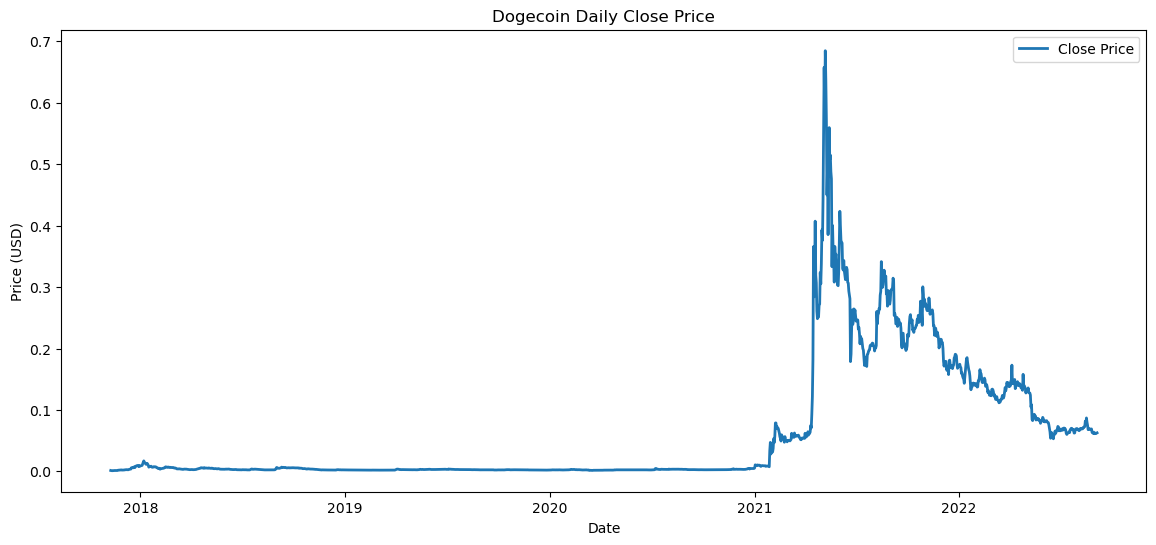

In [8]:
# 5. Exploratory Data Analysis
def plot_price_series(df):
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.title('Dogecoin Daily Close Price')
    plt.legend()
    plt.show()

plot_price_series(features_df)

In [9]:
# 6. Train/Test Split
# Use the last 30 days for evaluation for consistency with original
tail_window = 30
df_recent = features_df.tail(tail_window)

# Allocate indices
train = df_recent.iloc[:11].copy()
test = df_recent.iloc[11:].copy()

In [10]:
# 7. Modelling: Random Forest Regressor
# Prepare features and target
X_train = train.drop('Close', axis=1).values
y_train = train['Close'].values
X_test  = test.drop('Close', axis=1).values
y_test  = test['Close'].values

# Train Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

In [12]:
# 8. Evaluation Metrics
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.0056828405263158075
Root Mean Squared Error: 0.006270570119156473
R2 Score: 0.11396887257425481


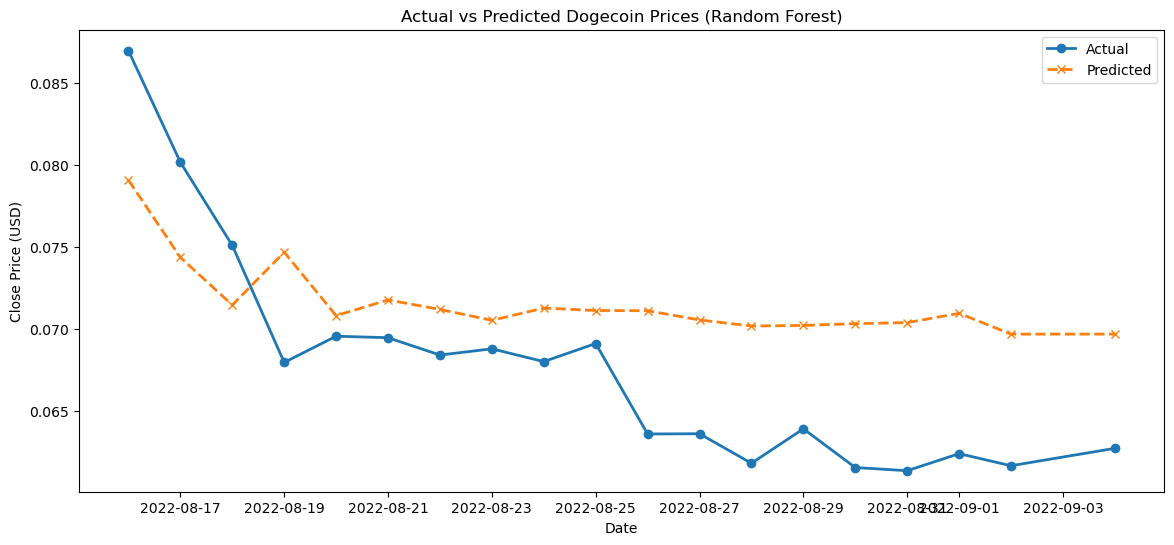

In [13]:
# 9. Visual Comparison
def plot_predictions(test_df, y_pred):
    plt.figure(figsize=(14, 6))
    plt.plot(test_df.index, test_df['Close'], 'o-', label='Actual', linewidth=2)
    plt.plot(test_df.index, y_pred, 'x--', label='Predicted', linewidth=2)
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.title('Actual vs Predicted Dogecoin Prices (Random Forest)')
    plt.legend()
    plt.show()

plot_predictions(test, y_pred)

### Title: "Actual vs Predicted Dogecoin Prices (Random Forest)"
- X-Axis: Date (from approximately 2022-08-17 to 2022-09-03)
- Y-Axis: "Close Price (USD)" (showing Dogecoin prices, ranging roughly 0.065 to 0.087 USD)
### Lines:
- The blue solid line with circles represents the Actual Dogecoin closing prices.
- The orange dashed line with x-marks represents the Predicted prices from the Random Forest model.
### Legend: Shows which line represents actual and which represents predicted values.
Trends Observed:
- The actual closing prices show a sharp initial drop and then small fluctuations.
- The predicted values also start high and follow a gentle downward trend but with less fluctuation and do not follow the actual dips and rises closely.

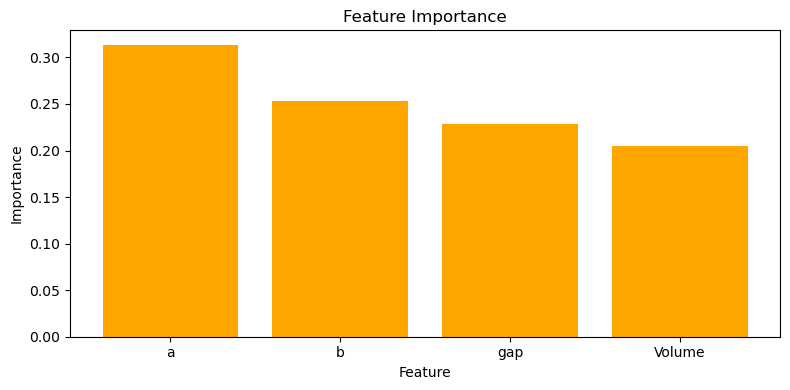

In [14]:
# 10. Feature Importance Plot
def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)[::-1]
    plt.figure(figsize=(8, 4))
    plt.bar([feature_names[i] for i in sorted_idx], importance[sorted_idx], color='orange')
    plt.title('Feature Importance')
    plt.xlabel('Feature')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf, train.drop('Close', axis=1).columns)

### X-Axis (Feature): The features used for prediction — a, b, gap, and Volume
- a: High / Low (a price ratio)
- b: (High / Low) * Volume
- gap: (High - Low) * Volume
- Volume: Trading volume
### Y-Axis (Importance): Quantifies each feature's importance as determined by the Random Forest model (higher means more important for predicting the target).
Observation:
The feature a (High / Low) is the most important (just above 0.3).
The next important are b, gap, and Volume, in that order, but all are fairly close in importance, between 0.2 and 0.3.